In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Berdasarkan hasil pengecekan dataset, diketahui bahwa dataset memiliki 7043 data dan 21 atribut. Dataset terdiri dari kombinasi data kategorikal dan numerik yang nantinya akan digunakan pada proses klasifikasi dan clustering. Selain itu, hasil pengecekan menunjukkan bahwa dataset tidak memiliki missing value sehingga data dapat langsung dilanjutkan ke tahap preprocessing.

In [6]:
df.duplicated().sum()

np.int64(0)

Hasil pengecekan menunjukkan bahwa dataset tidak memiliki data duplikat sehingga seluruh data dapat digunakan dalam proses analisis.

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
df.drop('customerID', axis=1, inplace=True)

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [16]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [20]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [21]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", rf_accuracy)

Accuracy Random Forest: 0.7998580553584103


Berdasarkan hasil pengujian, model Random Forest memperoleh tingkat akurasi sebesar 79%. Hasil tersebut menunjukkan bahwa model memiliki kemampuan yang cukup baik dalam memprediksi customer churn berdasarkan data pelanggan yang tersedia.

Meskipun model belum menghasilkan akurasi yang sangat tinggi, performa yang diperoleh sudah cukup baik untuk dataset real-world karena data pelanggan memiliki karakteristik yang cukup beragam.

In [22]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.67      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Hasil classification report menunjukkan bahwa model memiliki performa yang cukup baik dalam mengklasifikasikan pelanggan churn dan non-churn. Nilai precision pada kelas non-churn lebih tinggi dibandingkan kelas churn, yang menunjukkan bahwa model lebih mudah mengenali pelanggan yang tetap berlangganan dibanding pelanggan yang melakukan churn.

Selain itu, nilai recall pada kelas churn masih belum terlalu tinggi karena karakteristik pelanggan churn memiliki pola yang lebih kompleks dan beragam. Namun secara keseluruhan, model Random Forest sudah cukup baik digunakan untuk membantu prediksi customer churn pada dataset ini.

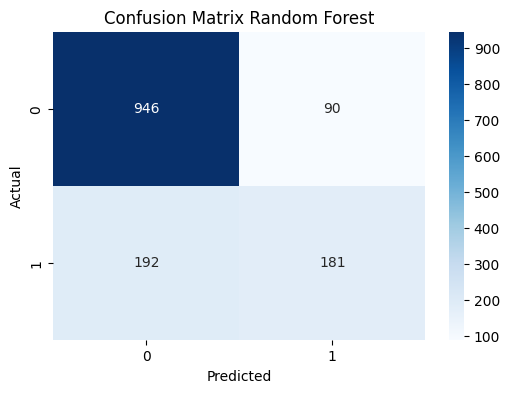

In [23]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Berdasarkan confusion matrix, sebagian besar data berhasil diprediksi dengan benar oleh model Random Forest. Meskipun demikian, masih terdapat beberapa kesalahan prediksi terutama pada kelas churn. Hal ini menunjukkan bahwa pola customer churn memiliki karakteristik yang cukup kompleks sehingga tidak seluruh data dapat diprediksi secara sempurna.

In [24]:
from sklearn.cluster import KMeans

In [25]:
inertia = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_train_scaled)

    inertia.append(kmeans.inertia_)

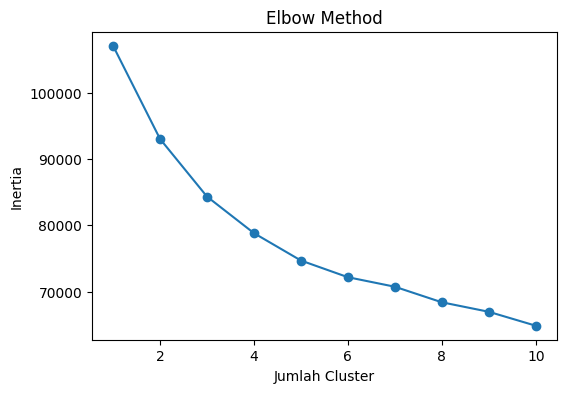

In [26]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')

plt.show()

Visualisasi Elbow Method digunakan untuk menentukan jumlah cluster optimal pada algoritma K-Means. Berdasarkan grafik yang dihasilkan, penurunan nilai inertia mulai melambat pada titik tertentu sehingga jumlah cluster dapat ditentukan berdasarkan titik elbow tersebut.

In [27]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_train_scaled)

In [28]:
cluster_df = X_train.copy()

cluster_df['Cluster'] = clusters

cluster_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cluster
2142,0,0,0,1,21,1,0,0,2,0,2,0,0,2,1,0,3,64.85,610,1
1623,0,0,0,0,54,1,2,1,0,2,0,0,2,2,2,1,0,97.20,4319,2
6074,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,2,23.45,1940,1
1362,1,0,0,0,4,1,0,1,0,0,0,0,0,0,0,1,2,70.20,2012,1
6754,1,0,0,1,0,1,2,0,2,2,0,2,0,0,2,1,0,61.90,0,1


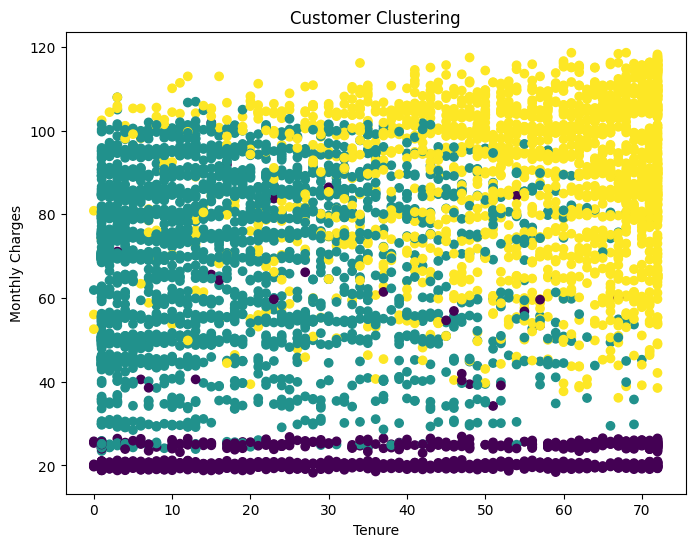

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    cluster_df['tenure'],
    cluster_df['MonthlyCharges'],
    c=cluster_df['Cluster']
)

plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.title('Customer Clustering')

plt.show()

Hasil clustering menunjukkan bahwa pelanggan dapat dikelompokkan berdasarkan karakteristik tertentu seperti lama berlangganan dan biaya bulanan. Setiap cluster memiliki pola yang berbeda sehingga dapat membantu perusahaan dalam memahami karakteristik pelanggan dengan lebih baik.

Cluster dengan nilai tenure tinggi cenderung menunjukkan pelanggan yang lebih loyal, sedangkan cluster dengan tenure rendah memiliki kemungkinan pelanggan yang lebih berisiko melakukan churn.

In [30]:
import joblib

In [31]:
joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [32]:
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

In [33]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [34]:
import os

os.listdir()

['.config',
 'scaler.pkl',
 'random_forest_model.pkl',
 'kmeans_model.pkl',
 'WA_Fn-UseC_-Telco-Customer-Churn.csv',
 'sample_data']

Model Random Forest, K-Means, dan StandardScaler disimpan dalam format .pkl agar dapat digunakan kembali pada tahap implementasi aplikasi web tanpa perlu melakukan proses training ulang.